# Hawkes Processes for Order Flow Alpha

## 1. Introduction and Simulation

This notebook introduces multivariate Hawkes processes and demonstrates:
- Basic properties and mathematical formulation
- Simulation using Ogata's thinning method
- Visualization of event sequences

### Mathematical Background

A multivariate Hawkes process is a self-exciting point process where the conditional intensity function for dimension $i$ is:

$$\lambda_i(t) = \mu_i + \sum_{j=1}^{d} \int_{-\infty}^{t} \phi_{ij}(t-s) \, dN_j(s)$$

where:
- $\mu_i$: baseline (exogenous) intensity
- $\phi_{ij}(t)$: excitation kernel from dimension $j$ to $i$
- $dN_j(s)$: counting process for dimension $j$

For exponential kernels: $\phi_{ij}(t) = \alpha_{ij} e^{-\beta_{ij} t}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / "src"))

from hawkes.utils.data_loader import simulate_hawkes_process
from hawkes.kernels import ExponentialKernel
from hawkes.diagnostics import StabilityDiagnostics

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Simulate a Hawkes Process

We'll simulate a 4-dimensional Hawkes process representing:
- Dimension 0: Market Buy (MB)
- Dimension 1: Market Sell (MS)
- Dimension 2: Limit Buy (LB)
- Dimension 3: Limit Sell (LS)

In [2]:
# Define true parameters
mu = np.array([0.5, 0.5, 1.0, 1.0])  # Baseline intensities

# Excitation matrix (alpha)
# Rows: target dimension, Columns: source dimension
alpha = np.array([
    [0.15, 0.05, 0.10, 0.02],  # MB triggered by...
    [0.05, 0.15, 0.02, 0.10],  # MS triggered by...
    [0.10, 0.02, 0.12, 0.05],  # LB triggered by...
    [0.02, 0.10, 0.05, 0.12]   # LS triggered by...
])

# Decay matrix (beta)
beta = np.ones((4, 4)) * 0.5

print("True Parameters:")
print(f"Baseline intensities (mu): {mu}")
print(f"\nExcitation matrix (alpha):\n{alpha}")
print(f"\nDecay matrix (beta):\n{beta}")

# Check stability
branching_ratio = alpha / beta
spectral_radius = np.max(np.abs(np.linalg.eigvals(branching_ratio)))
print(f"\nSpectral radius: {spectral_radius:.4f}")
print(f"Process is {'stable' if spectral_radius < 1 else 'unstable'}")

True Parameters:
Baseline intensities (mu): [0.5 0.5 1.  1. ]

Excitation matrix (alpha):
[[0.15 0.05 0.1  0.02]
 [0.05 0.15 0.02 0.1 ]
 [0.1  0.02 0.12 0.05]
 [0.02 0.1  0.05 0.12]]

Decay matrix (beta):
[[0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5]]

Spectral radius: 0.6119
Process is stable


In [3]:
# Simulate the process
np.random.seed(42)
T = 1000.0  # 1000 seconds
events = simulate_hawkes_process(mu, alpha, beta, T, seed=42)

# Summary statistics
event_labels = ['Market Buy', 'Market Sell', 'Limit Buy', 'Limit Sell']
print("\nSimulated Events:")
for i, (label, ev) in enumerate(zip(event_labels, events)):
    print(f"{label}: {len(ev)} events (rate: {len(ev)/T:.2f} Hz)")

total_events = sum(len(e) for e in events)
print(f"\nTotal: {total_events} events")


Simulated Events:
Market Buy: 1939 events (rate: 1.94 Hz)
Market Sell: 1949 events (rate: 1.95 Hz)
Limit Buy: 2341 events (rate: 2.34 Hz)
Limit Sell: 2347 events (rate: 2.35 Hz)

Total: 8576 events


## 3. Visualize Event Sequence

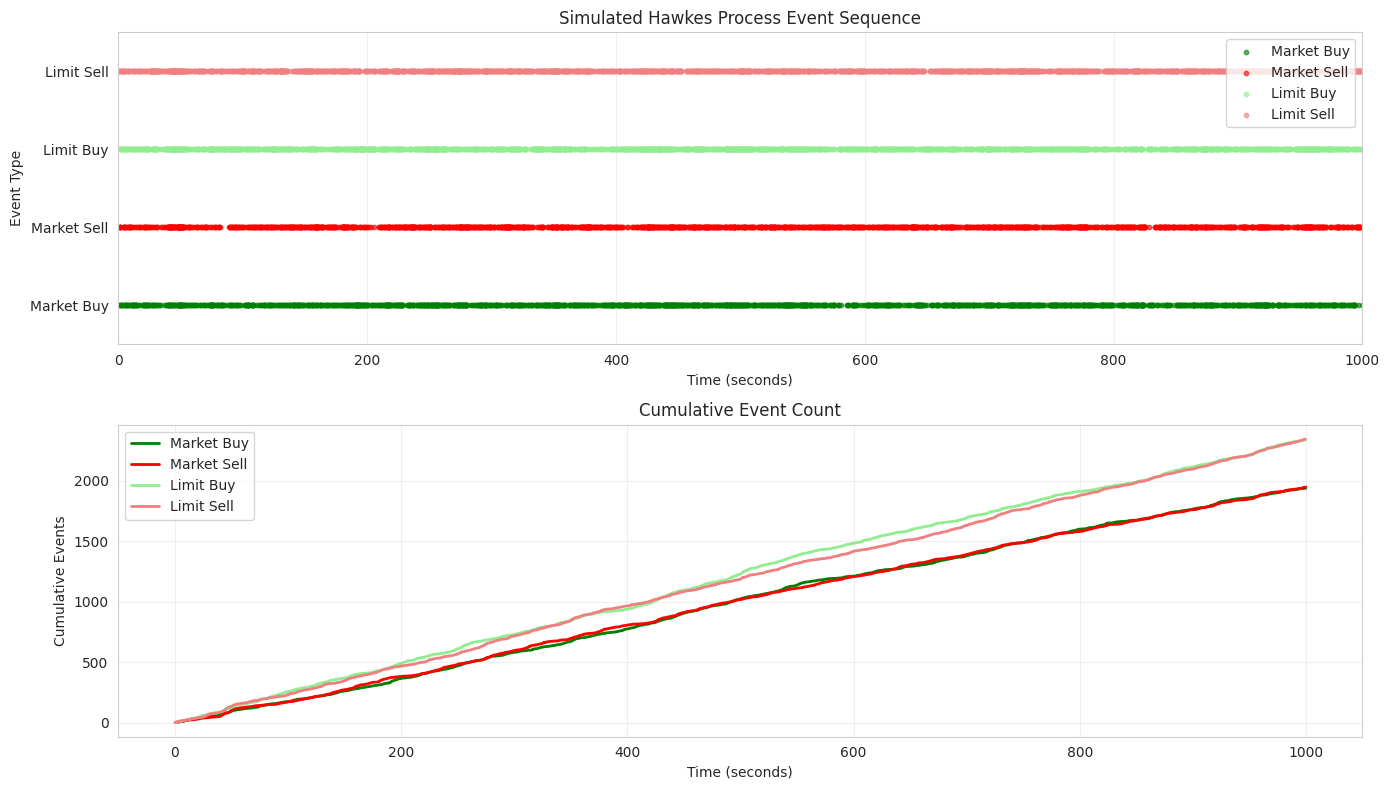

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Event raster plot
ax = axes[0]
colors = ['green', 'red', 'lightgreen', 'lightcoral']
for i, (ev, label, color) in enumerate(zip(events, event_labels, colors)):
    ax.scatter(ev, [i] * len(ev), c=color, s=10, alpha=0.6, label=label)
ax.set_xlim(0, T)
ax.set_ylim(-0.5, 3.5)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Event Type")
ax.set_yticks(range(4))
ax.set_yticklabels(event_labels)
ax.set_title("Simulated Hawkes Process Event Sequence")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Event count over time (cumulative)
ax = axes[1]
for ev, label, color in zip(events, event_labels, colors):
    ax.plot(np.sort(ev), np.arange(1, len(ev)+1), 
            color=color, label=label, linewidth=2)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Cumulative Events")
ax.set_title("Cumulative Event Count")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Inter-Event Time Distribution

Hawkes processes exhibit clustering, which manifests as:
- Heavy-tailed inter-event time distributions
- Overdispersion (variance > mean)

Market Buy: mean=0.515s, var=0.296, dispersion=0.575
Market Sell: mean=0.512s, var=0.312, dispersion=0.608
Limit Buy: mean=0.427s, var=0.208, dispersion=0.487
Limit Sell: mean=0.426s, var=0.207, dispersion=0.487


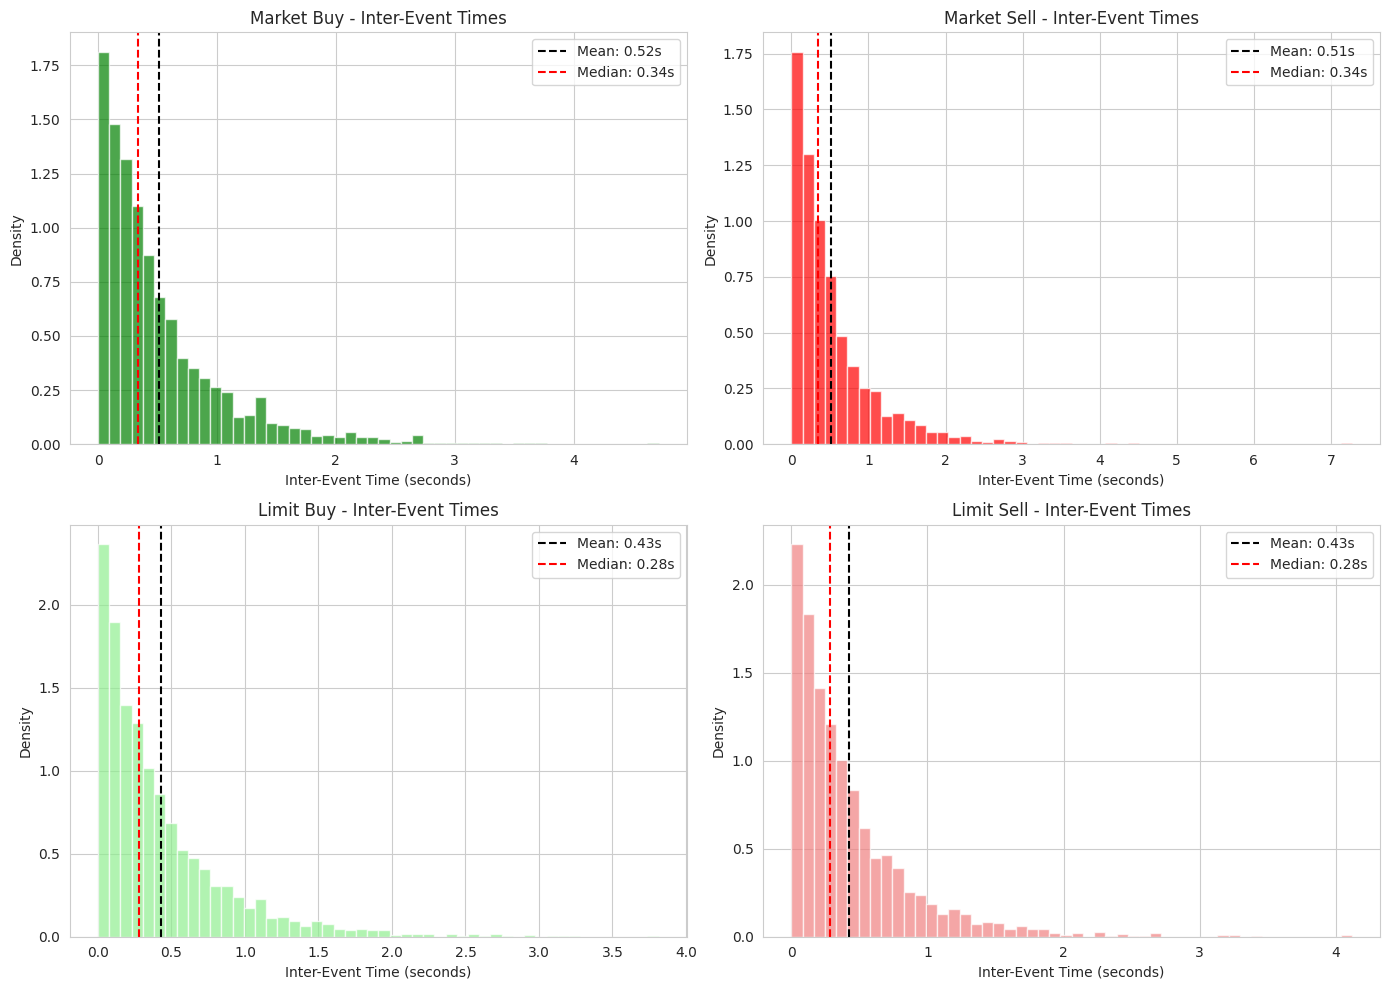

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (ev, label) in enumerate(zip(events, event_labels)):
    if len(ev) > 1:
        inter_times = np.diff(ev)
        ax = axes[i]
        ax.hist(inter_times, bins=50, density=True, alpha=0.7, color=colors[i])
        ax.axvline(np.mean(inter_times), color='black', 
                   linestyle='--', label=f'Mean: {np.mean(inter_times):.2f}s')
        ax.axvline(np.median(inter_times), color='red', 
                   linestyle='--', label=f'Median: {np.median(inter_times):.2f}s')
        ax.set_xlabel("Inter-Event Time (seconds)")
        ax.set_ylabel("Density")
        ax.set_title(f"{label} - Inter-Event Times")
        ax.legend()
        
        # Statistics
        mean_ie = np.mean(inter_times)
        var_ie = np.var(inter_times)
        dispersion = var_ie / mean_ie if mean_ie > 0 else 0
        print(f"{label}: mean={mean_ie:.3f}s, var={var_ie:.3f}, dispersion={dispersion:.3f}")

plt.tight_layout()
plt.show()

## 5. Stability Analysis

The branching ratio matrix $B_{ij} = \alpha_{ij} / \beta_{ij}$ determines the stability of the process.
For stationarity, the spectral radius $\rho(B) < 1$.


Stability Diagnostics:
Spectral radius: 0.6119
Stable: True
Total branching ratio: 2.4400
Endogenous ratio: 0.7093


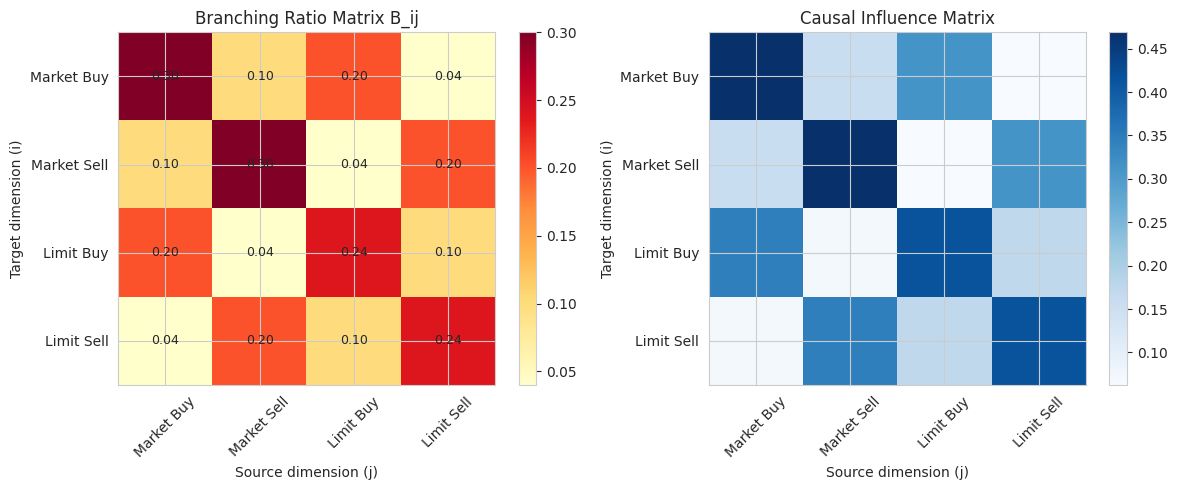

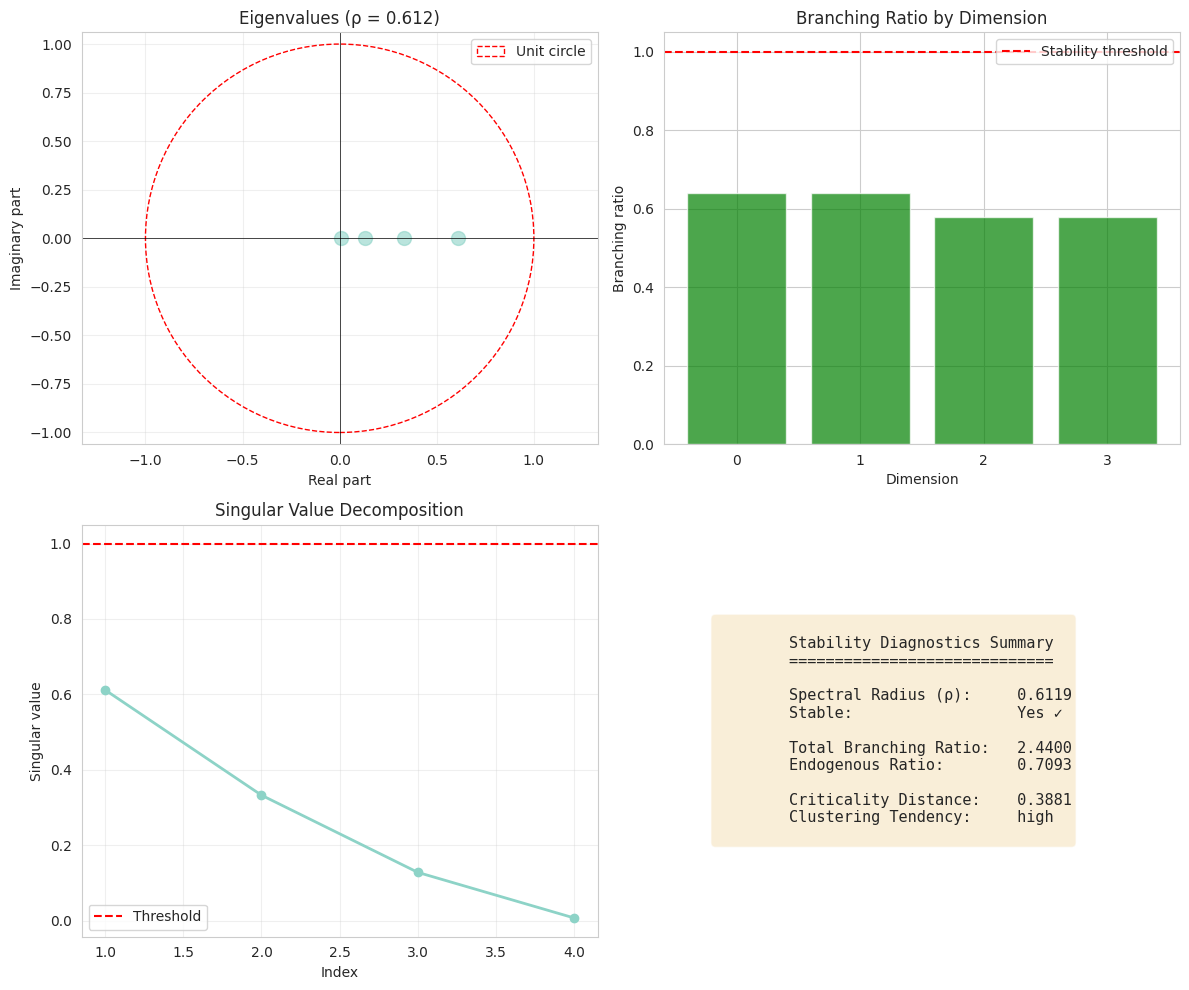

In [6]:
diagnostics = StabilityDiagnostics(branching_ratio)
report = diagnostics.generate_report()

print("\nStability Diagnostics:")
print(f"Spectral radius: {report['spectral_radius']:.4f}")
print(f"Stable: {report['is_stable']}")
print(f"Total branching ratio: {report['total_branching_ratio']:.4f}")
print(f"Endogenous ratio: {report['endogenous_ratio']:.4f}")

# Plot branching matrix
fig = diagnostics.plot_branching_matrix(event_labels)
plt.show()

# Plot stability analysis
fig = diagnostics.plot_stability_analysis()
plt.show()

## 6. Conclusion

In this notebook, we:
1. Defined the multivariate Hawkes process model
2. Simulated event sequences using Ogata's thinning method
3. Visualized the clustering behavior
4. Analyzed stability conditions

Next steps:
- [02_parameter_estimation.ipynb](02_parameter_estimation.ipynb): Estimate parameters from data
- [03_backtesting.ipynb](03_backtesting.ipynb): Test trading strategies